# Sección 6 (parte B): clasificación de AG News con embeddings

In [1]:
import json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim.downloader as api
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import utils as U
import evaluation as EV
import clasificacion as C

np.seterr(all="ignore")          # avisos espurios de matmul en Apple Silicon (ver evaluation._sims)
SEED, SEEDS = 42, [42, 43, 44]
CACHE = Path("cache"); RESULTS = Path("results"); FIGS = RESULTS / "figs"
FIGS.mkdir(parents=True, exist_ok=True)
pd.options.display.float_format = "{:.4f}".format

SGNS_RUNS = {"SGNS (d300)": "d300_c100", "SGNS (d100)": "d100_c100"}     # nombre mostrado -> run de A (<run>_W_in.npy)

/Users/marinesgarcia/Documents/UVG/DL/venv-lab7/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 6.1 Datos: split estratificado y OOV

In [2]:
D = C.load_agnews(val_frac=0.1, seed=SEED)
resumen = []
for split in ["train", "val", "test"]:
    y, toks = D[f"{split}_y"], D[f"{split}_tok"]
    resumen.append(dict(split=split, documentos=len(y), tokens=sum(map(len, toks)), tokens_por_doc=np.mean(list(map(len, toks))),
                        **{c: int((y == i).sum()) for i, c in enumerate(C.CLASSES)}))
pd.DataFrame(resumen).set_index("split")

/Users/marinesgarcia/Documents/UVG/DL/venv-lab7/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,documentos,tokens,tokens_por_doc,World,Sports,Business,Sci/Tech
split,,,,,,,
train,108000,4149307,38.4195,27000,27000,27000,27000
val,12000,460046,38.3372,3000,3000,3000,3000
test,7600,290684,38.2479,1900,1900,1900,1900


### Conjuntos de embeddings y porcentaje de tokens fuera de vocabulario (OOV)

In [3]:
gensim_space = EV.load_kv(CACHE / "gensim_d300_e3.kv", name="gensim (d300, 3 ep)")   # generado por gensim_glove.ipynb
glove_space = EV.EmbeddingSpace.from_keyed_vectors(api.load("glove-wiki-gigaword-100"), name="GloVe-100")
sgns_spaces = [EV.load_sgns(CACHE, r, name=n) for n, r in SGNS_RUNS.items()]
spaces = {s.name: s for s in [*sgns_spaces, gensim_space, glove_space] if s is not None}

inits = {"Aleatorio": dict(w2i=C.build_vocab(D["train_tok"], min_count=2), E=None)}
for n, s in spaces.items():
    E, w2i = C.embedding_table(s)
    inits[n] = dict(w2i=w2i, E=E)

filas = []
for n, cfg in inits.items():
    cfg["vocab_size"] = len(cfg["w2i"]) + 1                                  # +1: fila 0 = <unk>
    cfg["train"], cfg["val"], cfg["test"] = (C.Encoded(D[f"{k}_tok"], D[f"{k}_y"], cfg["w2i"]) for k in ("train", "val", "test"))
    cfg["dim"] = 100 if cfg["E"] is None else cfg["E"].shape[1]
    filas.append(dict(embeddings=n, vocabulario=len(cfg["w2i"]), dim=cfg["dim"],
                      **{f"OOV {k} (%)": C.oov_pct(D[f"{k}_tok"], cfg["w2i"]) for k in ("train", "val", "test")}))
oov = pd.DataFrame(filas).set_index("embeddings")
oov

,vocabulario,dim,OOV train (%),OOV val (%),OOV test (%)
embeddings,,,,,
Aleatorio,49822,100,0.7712,1.4131,1.3943
SGNS (d300),109644,300,3.7283,3.7177,3.6407
SGNS (d100),109644,100,3.7283,3.7177,3.6407
"gensim (d300, 3 ep)",109644,300,3.7283,3.7177,3.6407
GloVe-100,400000,100,1.2815,1.2464,1.2113


## 6.2 Baseline: TF-IDF + regresión logística

In [4]:
def uni_bi(toks):
    return toks + [a + " " + b for a, b in zip(toks, toks[1:])]

t0 = time.perf_counter()
tfidf = TfidfVectorizer(analyzer=uni_bi, min_df=2, sublinear_tf=True)
Xtr = tfidf.fit_transform(D["train_tok"]); Xva = tfidf.transform(D["val_tok"]); Xte = tfidf.transform(D["test_tok"])
t_vec = time.perf_counter() - t0
print(f"TF-IDF: {Xtr.shape[1]:,} características ({t_vec:.0f}s)")

cands = []
for Cval in [1, 3, 10, 30]:
    t0 = time.perf_counter()
    clf = LogisticRegression(C=Cval, max_iter=2000).fit(Xtr, D["train_y"])
    dt = time.perf_counter() - t0
    v = C.metrics(D["val_y"], clf.predict(Xva))
    cands.append(dict(C=Cval, **{f"val_{k}": x for k, x in v.items()}, train_time_s=dt + t_vec, clf=clf))
display(pd.DataFrame(cands).drop(columns="clf").set_index("C"))

best_lr = max(cands, key=lambda r: r["val_f1"])
tfidf_clf = best_lr["clf"]
tfidf_info = dict(name="TF-IDF + LogReg", C=best_lr["C"], n_features=Xtr.shape[1],
                  params_total=int(tfidf_clf.coef_.size + tfidf_clf.intercept_.size), params_trainable=int(tfidf_clf.coef_.size + tfidf_clf.intercept_.size),
                  train_time_s=best_lr["train_time_s"], val={k[4:]: v for k, v in best_lr.items() if k.startswith("val_")})
print("Elegido: C =", tfidf_info["C"])

TF-IDF: 428,247 características (3s)


,val_acc,val_precision,val_recall,val_f1,train_time_s
C,,,,,
1,0.9214,0.9212,0.9214,0.9212,15.3566
3,0.9261,0.9259,0.9261,0.9259,23.4009
10,0.9276,0.9274,0.9276,0.9274,27.1340
30,0.9236,0.9234,0.9236,0.9234,18.4990


Elegido: C = 10


## 6.3 Clasificador `EmbeddingBag` + MLP

In [5]:
EMB_LRS = [1e-3, 1e-2]
MAX_EPOCHS = 40


def entrenar(init, freeze, emb_lr, seed, verbose=False):
    cfg = inits[init]
    return C.train_classifier(cfg["train"], cfg["val"], cfg["vocab_size"], cfg["dim"], pretrained=cfg["E"], freeze=freeze,
                              epochs=MAX_EPOCHS, emb_lr=emb_lr, seed=seed, verbose=verbose, name=f"{init}/{'congelada' if freeze else 'entrenable'}")


variantes = []
for init in inits:
    variantes += [(init, "entrenada", False)] if init == "Aleatorio" else [(init, "congelada", True), (init, "fine-tuning", False)]

runs = {}
for init, modo, freeze in variantes:
    cand = [(entrenar(init, freeze, elr, SEED), elr) for elr in ([None] if freeze else EMB_LRS)]
    (model, info), elr = max(cand, key=lambda c: c[0][1]["val"]["f1"])
    info.update(init=init, modo=modo, emb_lr=elr, emb_lr_candidatos={str(l): round(i["val"]["f1"], 4) for (_, i), l in cand})
    runs[(init, modo)] = (model, info)
    print(f"{init:10s} {modo:12s} emb_lr={elr}  mejor epoch {info['best_epoch']:>2}  val F1 {info['val']['f1']:.4f}  ({info['train_time_s']:.0f}s)")

Aleatorio  entrenada    emb_lr=0.01  mejor epoch  2  val F1 0.9212  (5s)


SGNS (d300) congelada    emb_lr=None  mejor epoch 11  val F1 0.9019  (8s)


SGNS (d300) fine-tuning  emb_lr=0.001  mejor epoch  2  val F1 0.9202  (12s)


SGNS (d100) congelada    emb_lr=None  mejor epoch 29  val F1 0.8958  (13s)


SGNS (d100) fine-tuning  emb_lr=0.001  mejor epoch  2  val F1 0.9195  (6s)


gensim (d300, 3 ep) congelada    emb_lr=None  mejor epoch 29  val F1 0.9038  (22s)


gensim (d300, 3 ep) fine-tuning  emb_lr=0.001  mejor epoch  2  val F1 0.9196  (15s)


GloVe-100  congelada    emb_lr=None  mejor epoch 13  val F1 0.9076  (7s)


GloVe-100  fine-tuning  emb_lr=0.001  mejor epoch  5  val F1 0.9244  (11s)


In [6]:
# Variabilidad por semilla (mismos hiperparámetros elegidos, semillas 43 y 44; la 42 es la corrida principal)
for (init, modo), (model, info) in runs.items():
    f1s = [info["val"]["f1"]]
    for sd in SEEDS[1:]:
        f1s.append(entrenar(init, info["freeze"], info["emb_lr"], sd)[1]["val"]["f1"])
    info["val_f1_seeds"] = f1s

filas = [dict(modelo="TF-IDF + LogReg", variante=f"C={tfidf_info['C']}", emb_lr=None, mejor_epoch=None,
              **{f"val_{k}": v for k, v in tfidf_info["val"].items() if k != "loss"},
              params_total=tfidf_info["params_total"], params_entrenables=tfidf_info["params_trainable"],
              tiempo_s=tfidf_info["train_time_s"], val_f1_media=tfidf_info["val"]["f1"], val_f1_std=np.nan)]
for (init, modo), (model, info) in runs.items():
    filas.append(dict(modelo=init, variante=modo, emb_lr=info["emb_lr"], mejor_epoch=info["best_epoch"],
                      **{f"val_{k}": info["val"][k] for k in ("acc", "precision", "recall", "f1")},
                      params_total=info["params_total"], params_entrenables=info["params_trainable"], tiempo_s=info["train_time_s"],
                      val_f1_media=np.mean(info["val_f1_seeds"]), val_f1_std=np.std(info["val_f1_seeds"])))
tabla_val = pd.DataFrame(filas).set_index(["modelo", "variante"])
tabla_val.style.format({"emb_lr": "{:g}", "params_total": "{:,.0f}", "params_entrenables": "{:,.0f}", "tiempo_s": "{:.0f}"}, precision=4, na_rep="–")

### Curvas de pérdida de entrenamiento y validación

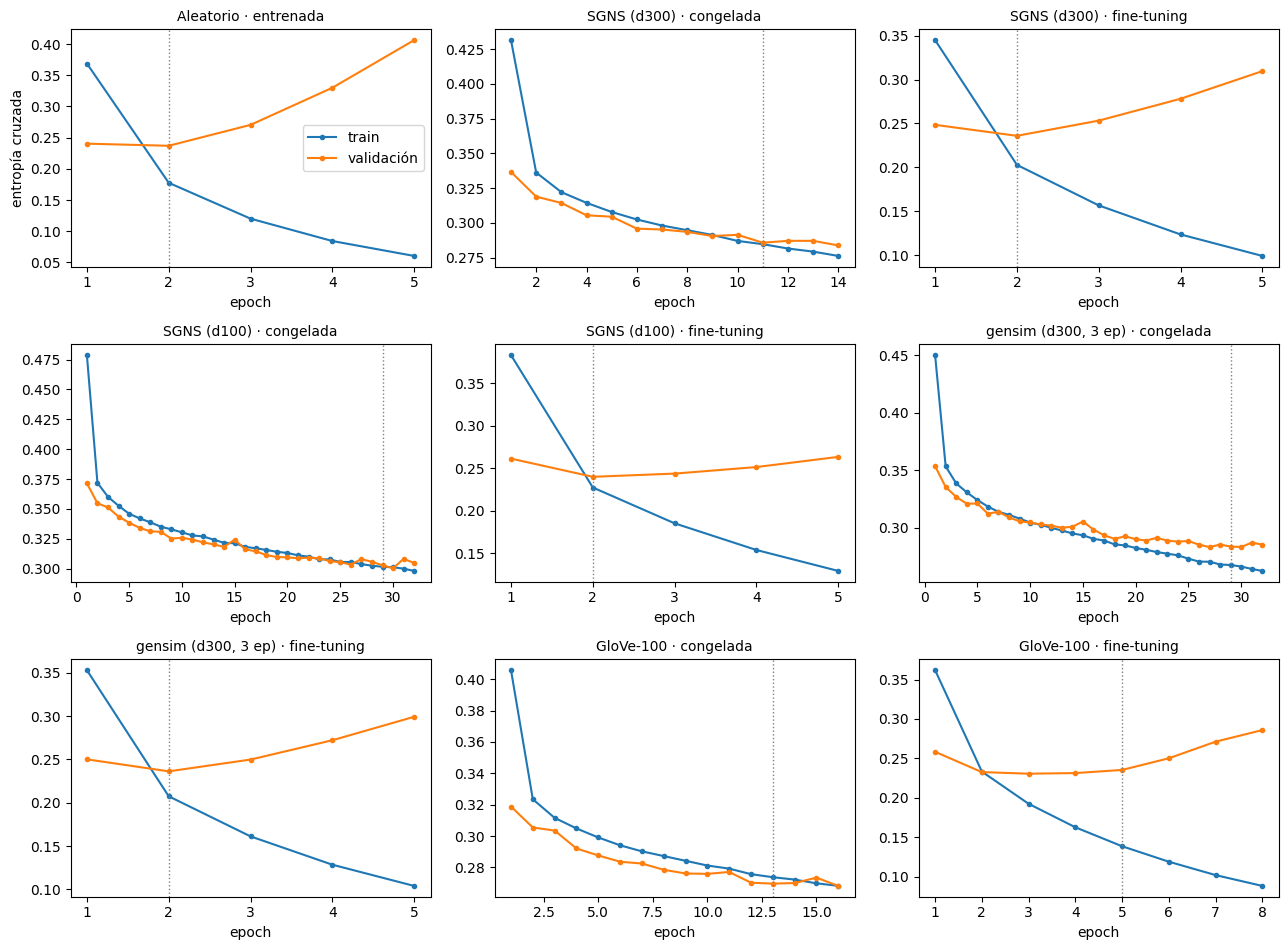

In [7]:
n = len(runs); cols = 3; rows = -(-n // cols)
fig, axes = plt.subplots(rows, cols, figsize=(4.3 * cols, 3.2 * rows), squeeze=False)
for ax, ((init, modo), (_, info)) in zip(axes.ravel(), runs.items()):
    h = pd.DataFrame(info["history"])
    ax.plot(h.epoch, h.train_loss, "o-", ms=3, label="train"); ax.plot(h.epoch, h.val_loss, "o-", ms=3, label="validación")
    ax.axvline(info["best_epoch"], color="gray", ls=":", lw=1)
    ax.set_title(f"{init} · {modo}", fontsize=10); ax.set_xlabel("epoch")
axes.ravel()[0].legend(); axes.ravel()[0].set_ylabel("entropía cruzada")
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.tight_layout(); plt.savefig(FIGS / "clasificacion_curvas_perdida.png", dpi=130); plt.show()

## 6.4 Evaluación final en test

In [8]:
mejor = {}
for init in inits:
    variantes_init = [(k, v) for k, v in runs.items() if k[0] == init]
    mejor[init] = max(variantes_init, key=lambda kv: np.mean(kv[1][1]["val_f1_seeds"]))
print({i: m[0][1] for i, m in mejor.items()})

test = {"TF-IDF + LogReg": None}
pred = tfidf_clf.predict(Xte)
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
test["TF-IDF + LogReg"] = dict(loss=np.nan, **C.metrics(D["test_y"], pred),
                               confusion=confusion_matrix(D["test_y"], pred).tolist(),
                               per_class_f1=precision_recall_fscore_support(D["test_y"], pred, zero_division=0)[2].tolist())
for init, ((_, modo), (model, info)) in mejor.items():
    test[f"{init} ({modo})"] = C.evaluate_test(model, inits[init]["test"])

tabla_test = pd.DataFrame({k: {m: v[m] for m in ("acc", "precision", "recall", "f1")} for k, v in test.items()}).T
tabla_test.columns = ["accuracy", "precision (macro)", "recall (macro)", "F1 (macro)"]
display(tabla_test)
display(pd.DataFrame({k: dict(zip(C.CLASSES, v["per_class_f1"])) for k, v in test.items()}).T.rename_axis("F1 por clase"))

{'Aleatorio': 'entrenada', 'SGNS (d300)': 'fine-tuning', 'SGNS (d100)': 'fine-tuning', 'gensim (d300, 3 ep)': 'fine-tuning', 'GloVe-100': 'fine-tuning'}


,accuracy,precision (macro),recall (macro),F1 (macro)
TF-IDF + LogReg,0.9234,0.9232,0.9234,0.9233
Aleatorio (entrenada),0.9196,0.9200,0.9196,0.9196
SGNS (d300) (fine-tuning),0.9171,0.9173,0.9171,0.9170
SGNS (d100) (fine-tuning),0.9166,0.9168,0.9166,0.9165
"gensim (d300, 3 ep) (fine-tuning)",0.9153,0.9153,0.9153,0.9151
GloVe-100 (fine-tuning),0.9184,0.9187,0.9184,0.9185


,World,Sports,Business,Sci/Tech
F1 por clase,,,,
TF-IDF + LogReg,0.9260,0.9688,0.8953,0.9029
Aleatorio (entrenada),0.9215,0.9705,0.8884,0.8981
SGNS (d300) (fine-tuning),0.9193,0.9706,0.8843,0.8940
SGNS (d100) (fine-tuning),0.9205,0.9709,0.8800,0.8945
"gensim (d300, 3 ep) (fine-tuning)",0.9187,0.9702,0.8805,0.8911
GloVe-100 (fine-tuning),0.9198,0.9709,0.8858,0.8973


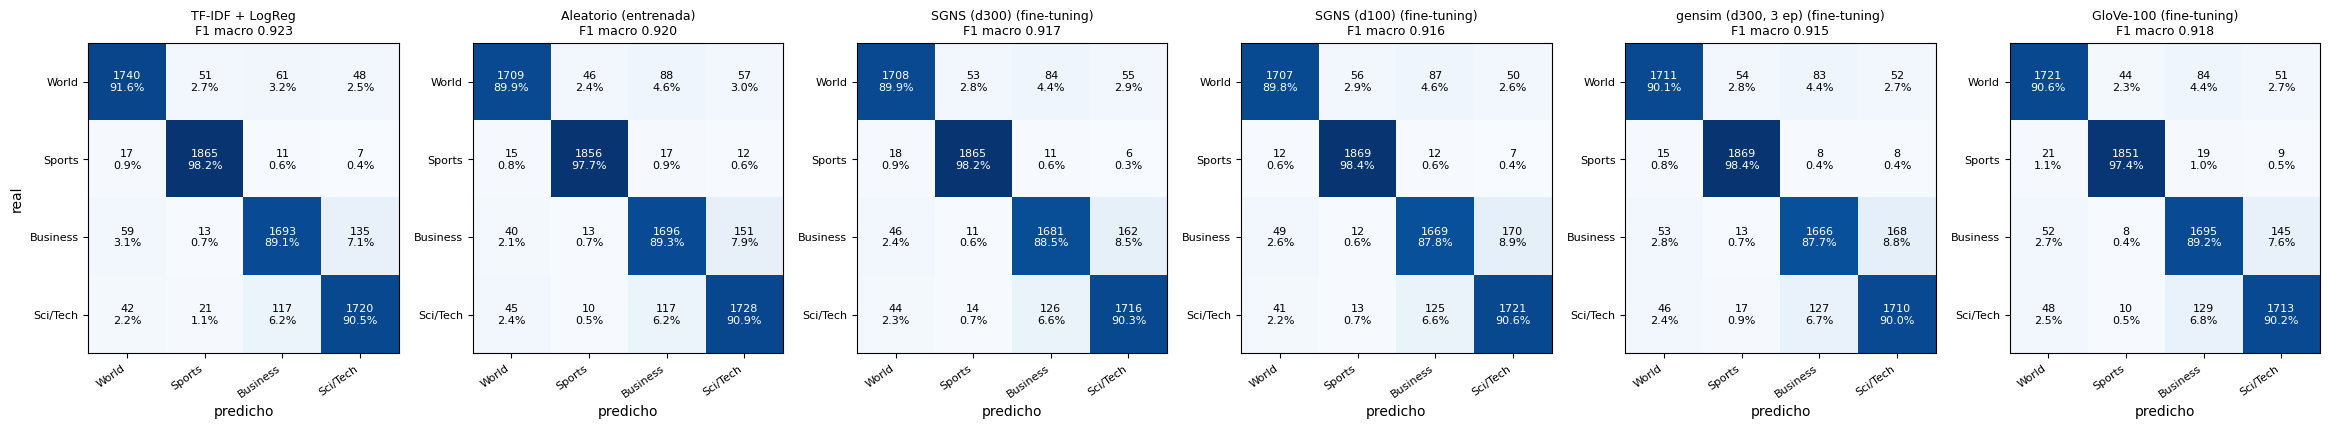

In [9]:
nm = len(test)
fig, axes = plt.subplots(1, nm, figsize=(3.9 * nm, 4.5))
for ax, (nombre, r) in zip(np.atleast_1d(axes), test.items()):
    cm = np.array(r["confusion"]); cmn = cm / cm.sum(1, keepdims=True)
    ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{cm[i, j]}\n{100 * cmn[i, j]:.1f}%", ha="center", va="center", fontsize=8,
                    color="white" if cmn[i, j] > 0.5 else "black")
    ax.set_xticks(range(4)); ax.set_xticklabels(C.CLASSES, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(range(4)); ax.set_yticklabels(C.CLASSES, fontsize=8)
    ax.set_title(f"{nombre}\nF1 macro {r['f1']:.3f}", fontsize=9); ax.set_xlabel("predicho")
np.atleast_1d(axes)[0].set_ylabel("real")
plt.tight_layout(rect=(0, 0, 1, 0.97)); plt.savefig(FIGS / "clasificacion_matrices_confusion.png", dpi=130); plt.show()

## 6.5 Correlación de Spearman en SimLex-999

In [10]:
wordsim, simlex = EV.load_word_pairs("wordsim353.tsv"), EV.load_word_pairs("simlex999.txt")
shared = EV.shared_vocabulary(list(spaces.values()), n=30000, order_by=gensim_space)
filas = []
for n, s in spaces.items():
    sl, ws, sl_sh = EV.word_similarity(s, simlex), EV.word_similarity(s, wordsim), EV.word_similarity(s.subset(shared), simlex)
    filas.append({"embeddings": n, "SimLex-999 (vocab propio)": sl["spearman"], "pares SimLex usados": sl["n_used"],
                  "SimLex-999 (vocab compartido)": sl_sh["spearman"], "pares (compartido)": sl_sh["n_used"],
                  "WordSim-353 (vocab propio)": ws["spearman"]})
tabla_sim = pd.DataFrame(filas).set_index("embeddings")
tabla_sim

,SimLex-999 (vocab propio),pares SimLex usados,SimLex-999 (vocab compartido),pares (compartido),WordSim-353 (vocab propio)
embeddings,,,,,
SGNS (d300),0.3350,995,0.3308,965,0.6898
SGNS (d100),0.3011,995,0.2951,965,0.6652
"gensim (d300, 3 ep)",0.3214,995,0.3172,965,0.6530
GloVe-100,0.2975,999,0.3072,965,0.5327


In [11]:
salida = dict(
    oov=oov.to_dict(orient="index"),
    tfidf=tfidf_info,
    val={f"{i}/{m}": dict(info={k: v for k, v in inf.items() if k != "history"}, history=inf["history"]) for (i, m), (_, inf) in runs.items()},
    mejor_variante={i: m[0][1] for i, m in mejor.items()},
    test=test,
    simlex=tabla_sim.reset_index().to_dict(orient="records"),
    modelos_embeddings=list(spaces), sgns_incluidos=[s.name for s in sgns_spaces if s is not None],
    procedencia={n: (dict(modelo="SGNS propio (PyTorch, desde cero)", run=SGNS_RUNS[n], matriz=f"{SGNS_RUNS[n]}_W_in.npy") if n in SGNS_RUNS else
                     dict(modelo="Word2Vec de gensim", run="gensim_d300_e3", config="ver results/gensim_d300_e3.json") if n.startswith("gensim") else
                     dict(modelo="GloVe preentrenado (glove-wiki-gigaword-100)", run="glove-wiki-gigaword-100")) for n in spaces},
    clasificador=dict(arquitectura="EmbeddingBag(mean) -> Linear(d,256) -> ReLU -> Dropout(0.3) -> Linear(256,4)", max_epochs=MAX_EPOCHS, patience=3, emb_lr_candidatos=EMB_LRS, seeds=SEEDS, val_frac=0.1, split_seed=SEED),
)
json.dump(salida, open(RESULTS / "clasificacion_B.json", "w"), indent=1, default=float)
print("Guardado en", RESULTS / "clasificacion_B.json")

Guardado en results/clasificacion_B.json
